In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
FILE="pubg.csv"

In [3]:
# load the data
df=pd.read_csv(FILE,low_memory=False)

In [4]:
# quick overview

print("shape :",df.shape)
print("\ncolumns :",df.columns.tolist())
print("\ndata types(first 30)")
display(df.dtypes.head(30))

shape : (4446966, 29)

columns : ['Id', 'groupId', 'matchId', 'assists', 'boosts', 'damageDealt', 'DBNOs', 'headshotKills', 'heals', 'killPlace', 'killPoints', 'kills', 'killStreaks', 'longestKill', 'matchDuration', 'matchType', 'maxPlace', 'numGroups', 'rankPoints', 'revives', 'rideDistance', 'roadKills', 'swimDistance', 'teamKills', 'vehicleDestroys', 'walkDistance', 'weaponsAcquired', 'winPoints', 'winPlacePerc']

data types(first 30)


Id                  object
groupId             object
matchId             object
assists              int64
boosts               int64
damageDealt        float64
DBNOs                int64
headshotKills        int64
heals                int64
killPlace            int64
killPoints           int64
kills                int64
killStreaks          int64
longestKill        float64
matchDuration        int64
matchType           object
maxPlace             int64
numGroups            int64
rankPoints           int64
revives              int64
rideDistance       float64
roadKills            int64
swimDistance       float64
teamKills            int64
vehicleDestroys      int64
walkDistance       float64
weaponsAcquired      int64
winPoints            int64
winPlacePerc       float64
dtype: object

In [5]:
# this will show first 10 rows
df.head(10)

,Id,groupId,matchId,assists,boosts,damageDealt,DBNOs,headshotKills,heals,killPlace,...,revives,rideDistance,roadKills,swimDistance,teamKills,vehicleDestroys,walkDistance,weaponsAcquired,winPoints,winPlacePerc
0,7f96b2f878858a,4d4b580de459be,a10357fd1a4a91,0,0,0.000,0,0,0,60,...,0,0.0000,0,0.00,0,0,244.80,1,1466,0.4444
1,eef90569b9d03c,684d5656442f9e,aeb375fc57110c,0,0,91.470,0,0,0,57,...,0,0.0045,0,11.04,0,0,1434.00,5,0,0.6400
2,1eaf90ac73de72,6a4a42c3245a74,110163d8bb94ae,1,0,68.000,0,0,0,47,...,0,0.0000,0,0.00,0,0,161.80,2,0,0.7755
3,4616d365dd2853,a930a9c79cd721,f1f1f4ef412d7e,0,0,32.900,0,0,0,75,...,0,0.0000,0,0.00,0,0,202.70,3,0,0.1667
4,315c96c26c9aac,de04010b3458dd,6dc8ff871e21e6,0,0,100.000,0,0,0,45,...,0,0.0000,0,0.00,0,0,49.75,2,0,0.1875
5,ff79c12f326506,289a6836a88d27,bac52627a12114,0,0,100.000,1,1,0,44,...,0,0.0000,0,0.00,0,0,34.70,1,0,0.0370
6,95959be0e21ca3,2c485a1ad3d0f1,a8274e903927a2,0,0,0.000,0,0,0,96,...,0,0.0000,0,0.00,0,0,13.50,1,1497,0.0000
7,311b84c6ff4390,eaba5fcb7fc1ae,292611730ca862,0,0,8.538,0,0,0,48,...,0,2004.0000,0,0.00,0,0,1089.00,6,1500,0.7368
8,1a68204ccf9891,47cfbb04e1b1a2,df014fbee741c6,0,0,51.600,0,0,0,64,...,0,0.0000,0,0.00,0,0,799.90,4,0,0.3704
9,e5bb5a43587253,759bb6f7514fd2,3d3031c795305b,0,0,37.270,0,0,0,74,...,0,0.0000,0,0.00,0,0,65.67,1,0,0.2143


In [6]:
# looking for missing values 
display(df.isna().sum().sort_values(ascending=False).head(20))

winPlacePerc       1
matchType          0
winPoints          0
weaponsAcquired    0
walkDistance       0
vehicleDestroys    0
teamKills          0
swimDistance       0
roadKills          0
rideDistance       0
revives            0
rankPoints         0
numGroups          0
maxPlace           0
Id                 0
groupId            0
longestKill        0
killStreaks        0
kills              0
killPoints         0
dtype: int64

In [7]:
# chake duplicates values

df.duplicated().sum()

0

In [8]:
# basic numeric summery for key numeric columns 

num_cols=[c for c in ['kills','damageDealt','assists','DBNOs','headshotKills','heals','killPlace','killPoints','killSteaks','longestKill','matchDuration','maxplace','rankPoints','revives','boosts'] if c in df.columns]
print("\n Numeric summary for selected features:")


display(df[num_cols].describe().T)


 Numeric summary for selected features:


,count,mean,std,min,25%,50%,75%,max
kills,4446966.0,0.924783,1.558445,0.0,0.0,0.00,1.00,72.0
damageDealt,4446966.0,130.717138,170.780621,0.0,0.0,84.24,186.00,6616.0
assists,4446966.0,0.233815,0.588573,0.0,0.0,0.00,0.00,22.0
DBNOs,4446966.0,0.657876,1.145743,0.0,0.0,0.00,1.00,53.0
headshotKills,4446966.0,0.226820,0.602155,0.0,0.0,0.00,0.00,64.0
heals,4446966.0,1.370147,2.679982,0.0,0.0,0.00,2.00,80.0
killPlace,4446966.0,47.599350,27.462937,1.0,24.0,47.00,71.00,101.0
killPoints,4446966.0,505.006042,627.504896,0.0,0.0,0.00,1172.00,2170.0
longestKill,4446966.0,22.997595,50.972619,0.0,0.0,0.00,21.32,1094.0
matchDuration,4446966.0,1579.506440,258.739856,9.0,1367.0,1438.00,1851.00,2237.0


In [9]:
# catagorical overview for matchtype (if exists)
if 'matchType' in df.columns:
    print("\n matchType value counts (top 20):")
    display(df['matchType'].value_counts().head(20))


 matchType value counts (top 20):


matchType
squad-fpp           1756186
duo-fpp              996691
squad                626526
solo-fpp             536762
duo                  313591
solo                 181943
normal-squad-fpp      17174
crashfpp               6287
normal-duo-fpp         5489
flaretpp               2505
normal-solo-fpp        1682
flarefpp                718
normal-squad            516
crashtpp                371
normal-solo             326
normal-duo              199
Name: count, dtype: int64

In [10]:
# memory usage
print("\n Memory usege (MB):")
mem=df.memory_usage(deep=True).sum()/(1024**2)
print(round(mem,2))


 Memory usege (MB):
1888.39


In [11]:
# saving a small sample VSC 
sample_path = r"C:/Users/valak/Favorites/Downloads/game_winner_prediction/PUBG_sample.csv"
df.head(50).to_csv(sample_path,index=False)
print(f"\nSaved first 50 rows to: (sample_path)")


Saved first 50 rows to: (sample_path)


## EDA

In [12]:
# target variable check

[target for target in["winPlace","winplaceperc","winPoints"]if target in df.columns]

['winPoints']

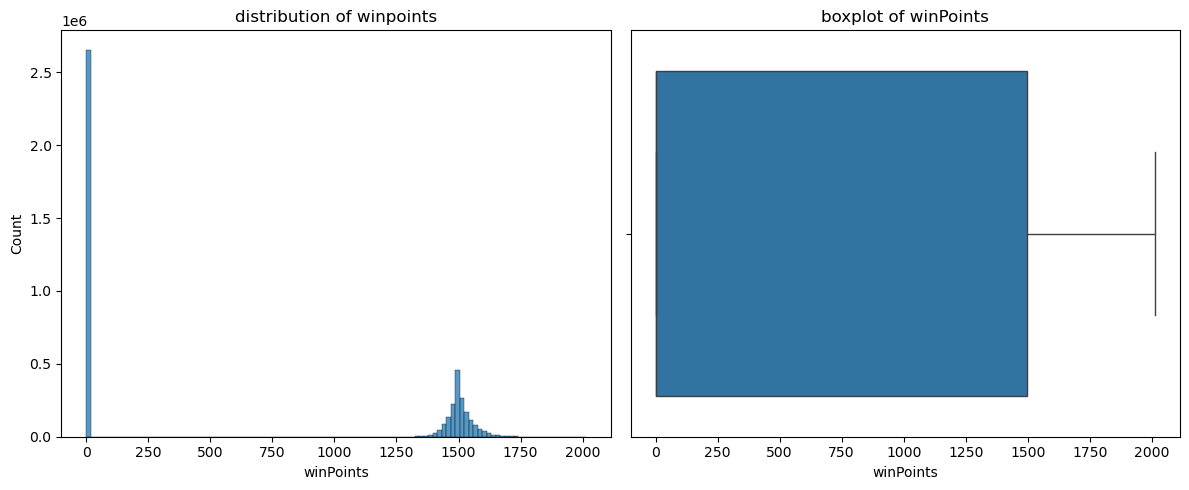

count    4.446966e+06
mean     6.064601e+02
std      7.397004e+02
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      1.495000e+03
max      2.013000e+03
Name: winPoints, dtype: float64

In [13]:
# univariate Analysis on winpoints
plt.figure(figsize=(12,5))

#distribution plot
plt.subplot(1,2,1)
sns.histplot(df['winPoints'])
plt.title('distribution of winpoints')

#boxplot
plt.subplot(1,2,2)
sns.boxplot(x=df['winPoints'])
plt.title('boxplot of winPoints')

plt.tight_layout()
plt.show()

#summary statistic
df['winPoints'].describe()

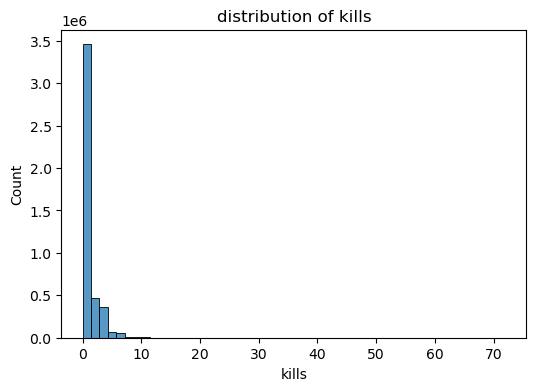

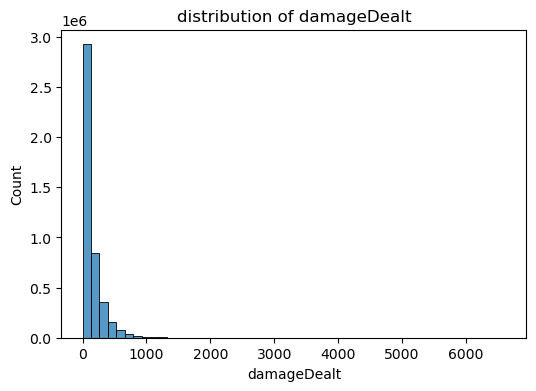

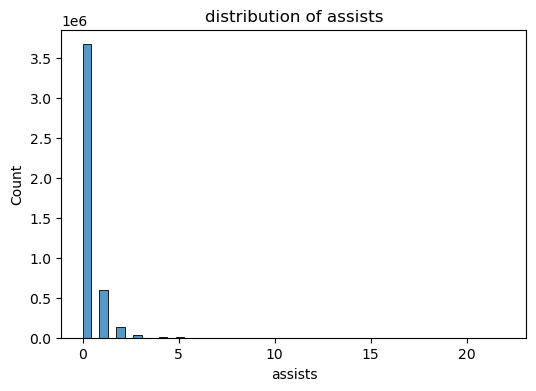

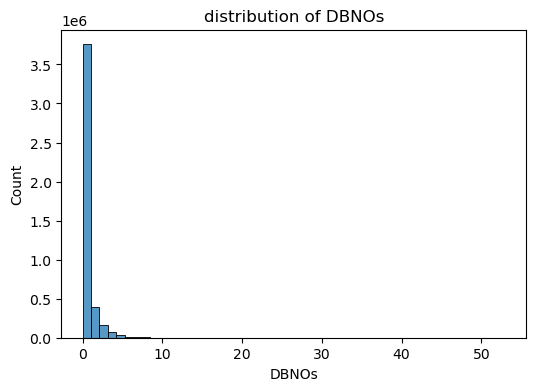

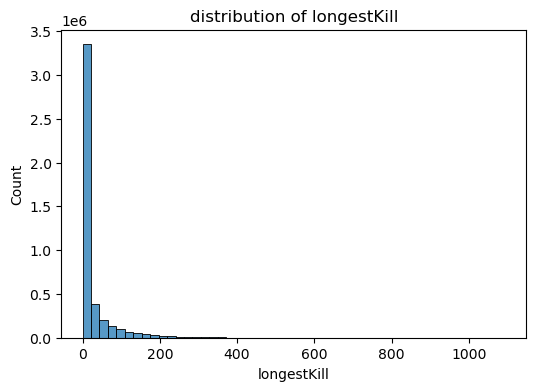

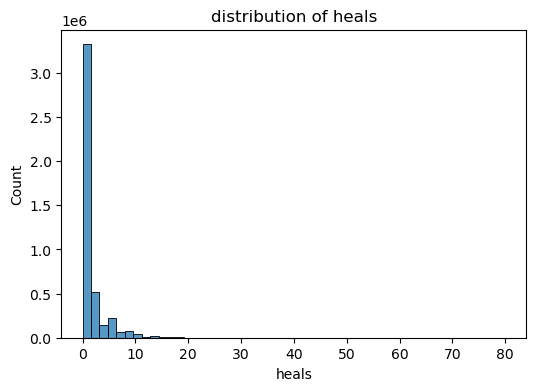

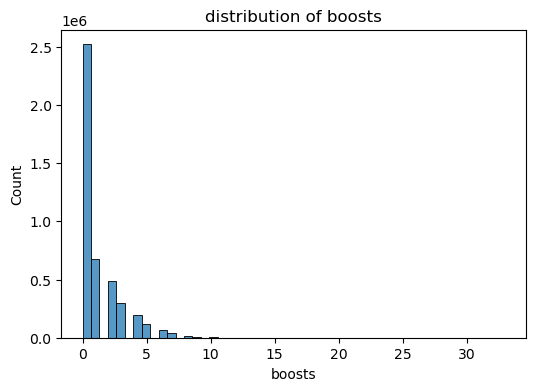

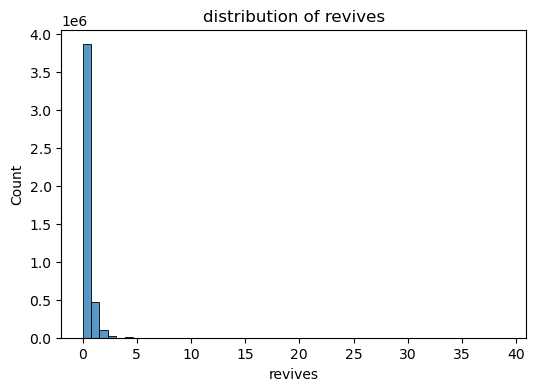

In [14]:
# distribution plots for key features
num_cols=["kills","damageDealt","assists","DBNOs","longestKill",
            "heals","boosts","revives"]
for col in num_cols:
    if col in df.columns:
        plt.figure(figsize=(6,4))
        sns.histplot(df[col],bins=50)
        plt.title(f"distribution of {col}")
        plt.show()

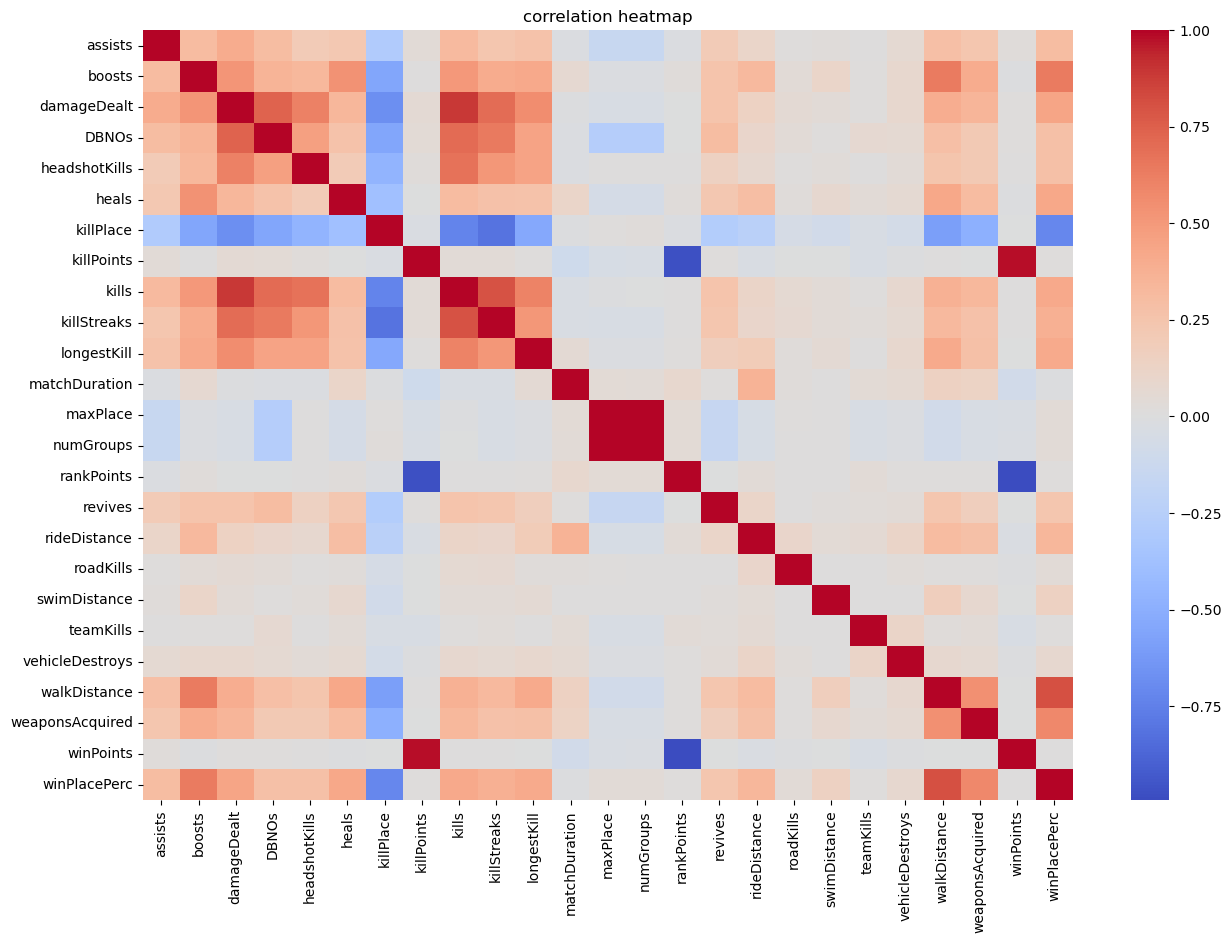

In [15]:
# correlation heatmap
df_numeric=df.drop(['Id','groupId','matchId'],axis=1)   #droping columns which contain string values

df_numeric=df_numeric.select_dtypes(include=['number'])  #this will chose only numeric value for heatmap

plt.figure(figsize=(15,10))
sns.heatmap(df_numeric.corr(),cmap="coolwarm",annot=False)
plt.title("correlation heatmap")
plt.show()

In [16]:
#match type analysis
if"matchType" in df.columns:
    df["matchType"].value_counts().head(20)

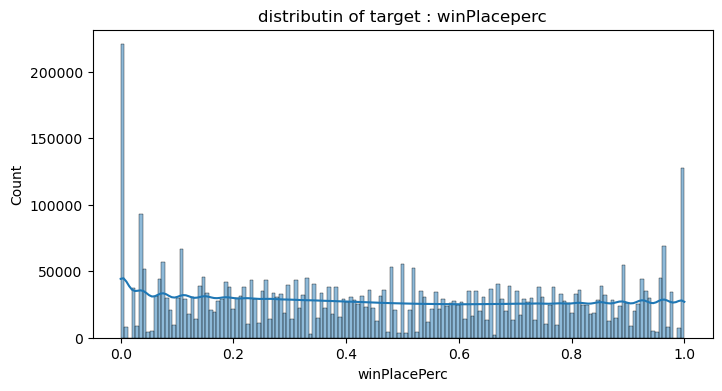

In [17]:
# distribution of target variable 

plt.figure(figsize=(8,4))
sns.histplot(df['winPlacePerc'], kde=True)
plt.title("distributin of target : winPlaceperc")
plt.show()                                                   #this shows how balanced the target is

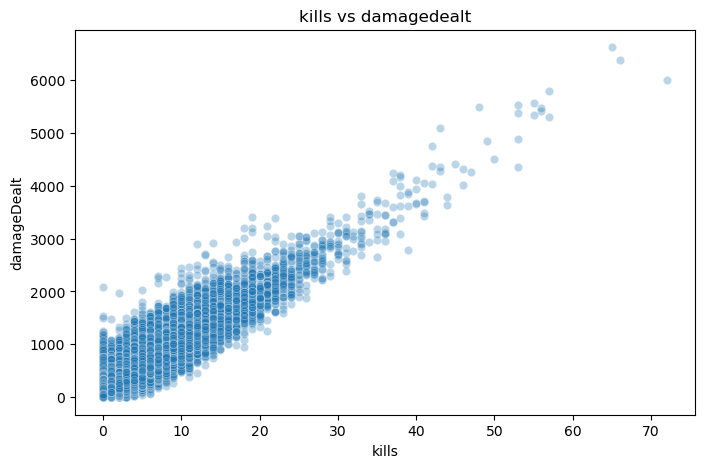

In [18]:
# feature interaction - kills vs damagede dealt

plt.figure(figsize=(8,5))
sns.scatterplot(x=df['kills'],y=df['damageDealt'],alpha=0.3)
plt.title("kills vs damagedealt")
plt.show()

In [19]:
# correlation with target (top 10)

target_corr=df_numeric.corr()['winPlacePerc'].sort_values(ascending=False)
target_corr.head(10)

winPlacePerc       1.000000
walkDistance       0.810888
boosts             0.634234
weaponsAcquired    0.583806
damageDealt        0.440507
heals              0.427857
kills              0.419916
longestKill        0.410154
killStreaks        0.377566
rideDistance       0.342915
Name: winPlacePerc, dtype: float64

## DATA CLEANING & PREPROCESSING

In [20]:
# remove columns which are not useful for prediction

df.drop(['Id','groupId','matchId'],axis=1,inplace=True)

In [21]:
# handle missing values

df.isnull().sum()

assists            0
boosts             0
damageDealt        0
DBNOs              0
headshotKills      0
heals              0
killPlace          0
killPoints         0
kills              0
killStreaks        0
longestKill        0
matchDuration      0
matchType          0
maxPlace           0
numGroups          0
rankPoints         0
revives            0
rideDistance       0
roadKills          0
swimDistance       0
teamKills          0
vehicleDestroys    0
walkDistance       0
weaponsAcquired    0
winPoints          0
winPlacePerc       1
dtype: int64

In [22]:
df=df.dropna(subset=['winPlacePerc'])

In [23]:
# convert categoriical column to numeric using label encoding

from sklearn.preprocessing import LabelEncoder

le=LabelEncoder()
df['matchType']=le.fit_transform(df['matchType'])

### feature scaling 

In [24]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
x_scaled=scaler.fit_transform(df.drop('winPlacePerc',axis=1))

### prepare final features & target

In [38]:
x=df.drop('winPlacePerc',axis=1)
y=df['winPlacePerc']

## train-test split

In [45]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x_scaled,y,test_size=0.2,random_state=42)

# model building

In [28]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score

lr=LinearRegression()
lr.fit(x_train,y_train)

y_pred_lr=lr.predict(x_test)
lr_mse=mean_squared_error(y_test,y_pred_lr)
lr_r2=r2_score(y_test,y_pred_lr)

lr_mse,lr_r2

(0.015847499991172853, 0.8320651999399982)

# random forest model

In [29]:
from sklearn.ensemble import RandomForestRegressor

rf=RandomForestRegressor(n_estimators=40,max_depth=10,n_jobs=-1,random_state=42)
rf.fit(x_train,y_train)

y_pred_rf=rf.predict(x_test)

rf_mse=mean_squared_error(y_test,y_pred_rf)
rf_r2=r2_score(y_test,y_pred_rf)

rf_mse,rf_r2

(0.00914237492296356, 0.9031189206110337)

# gradient boosting regressor model

In [30]:
from sklearn.ensemble import GradientBoostingRegressor
gbr_model=GradientBoostingRegressor(random_state=42)
gbr_model.fit(x_train,y_train)

gbr_pred=gbr_model.predict(x_test)

gbr_mse=mean_squared_error(y_test,gbr_pred)
gbr_r2=r2_score(y_test,gbr_pred)

gbr_mse,gbr_r2

(0.009504987985070932, 0.8992763364735946)

## compare all models

In [47]:
print("linear regration R2          : ",lr_r2)
print("random forest R2             : ",rf_r2)
print("gradient boosting regresor R2: ",gbr_r2)

linear regration R2          :  0.8320651999399982
random forest R2             :  0.9031189206110337
gradient boosting regresor R2:  0.8992763364735946


### Project Summary ###
The goal of this project was to predict the final winning percentage (winPlacePerc) of PUBG players using match statistics. 
We performed complete data preprocessing, feature engineering, exploratory data analysis, model building, and evaluation. 
Three regression models were trained and compared: Linear Regression, Random Forest Regressor, and Gradient Boosting Regressor.

### Best Model ###
Based on the R² score and error metrics, the Random Forest model performed the best overall. 
It captured non-linear relationships effectively and produced the lowest prediction error.

### Conclusion ###
The project successfully developed a machine learning model to predict winPlacePerc in PUBG. 
The Random Forest model achieved the best performance, indicating strong capability in modeling complex game features. 
This model can help identify key performance indicators and estimate a player's match outcome with high accuracy.